# NSCH EDA 

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from pathlib import Path

## Data Preparation

Begin with 2018 as that is the first year that screentime variable was introduced

In [66]:
files = {
    2018: '/Users/hannahw/dtsc-capstone/data/nsch_2018e_topical.sas7bdat',
    2019: '/Users/hannahw/dtsc-capstone/data/nsch_2019e_topical.sas7bdat',
    2020: '/Users/hannahw/dtsc-capstone/data/nsch_2020e_topical.sas7bdat',
    2021: '/Users/hannahw/dtsc-capstone/data/nsch_2021e_topical.sas7bdat',
    2022: '/Users/hannahw/dtsc-capstone/data/nsch_2022e_topical.sas7bdat',
    2023: '/Users/hannahw/dtsc-capstone/data/nsch_2023e_topical.sas7bdat',
    2024: '/Users/hannahw/dtsc-capstone/data/nsch_2024e_topical.sas7bdat',
}

Selecting relevant columns

In [67]:
keep_cols = [
    'HHID',
    'SCREENTIME',
    'K2Q31A',
    'K2Q31C',
    'K2Q31D',
    'K2Q32A',
    'K2Q32C',
    'K2Q33A',
    'K2Q33C',
    'K2Q34A',
    'K2Q34C',
    'SC_AGE_YEARS',
    'SC_SEX',
    'SC_RACE_R',
    'GRADES',
    'HIGRADE',
    'PHYSACTIV',
    'K4Q22_R',
    'AUTISMMED',
    'AUTISMTREAT',
    'K2Q35C',
    'K2Q36A',
    'K2Q36C',
    'K2Q37A',
    'K2Q37C',
    'MEMORYCOND',
    'ASKQUESTION',
    'ASKQUESTION2',
    'CALMDOWN_R',
    'CLEAREXP',
    'DIRECTIONS',
    'DIRECTIONS2',
    'DISTRACTED',
    'FOCUSON',
    'HARDWORK',
    'HURTSAD',
    'K6Q70_R',
    'K6Q71_R',
    'K6Q72_R',
    'K6Q73_R',
    'K7Q04R_R',
    'K7Q30',
    'K7Q31',
    'K7Q33',
    'K7Q38',
    'K7Q82_R',
    'K7Q83_R',
    'K7Q84_R',
    'K7Q85_R',
    'MAKEFRIEND',
    'NAMEEMOTIONS',
    'PLAYWELL',
    'SHARETOYS',
    'TELLSTORY',
    'TEMPER_R',
    'UNDERSTAND',
    'WAITFORTURN',
    'BEDTIME',
    'K6Q60_R',
]

Merge Data

In [68]:
dfs = []
for year, path in files.items():
    df = pd.read_sas(path)
    df['YEAR'] = year
    cols = [c for c in keep_cols if c in df.columns]
    dfs.append(df[cols + ['YEAR']])

combined = pd.concat(dfs, ignore_index=True)

Determine how many missing rows there are for screentime variable

In [69]:
print(combined['SCREENTIME'].isna().sum())
print(combined['SCREENTIME'].isna().mean() * 100) 

5173
1.6460263720598716


Since only 1.6% of the screen time values are missing, we will just drop them.

In [70]:
df = combined.dropna(subset=['SCREENTIME'])

Convert household ID from byte to string

In [71]:
df['HHID'] = df['HHID'].str.decode('utf-8')

## Data Mapping

Mapping screentime ranking to labels representing time in hours spent on screens 

In [72]:
screentime_labels = {
    1: 'Less than 1 hour',
    2: '1 hour',
    3: '2 hours',
    4: '3 hours',
    5: '4 or more hours'
}
screentime_labels_short = {1: '<1 hr', 2: '1 hr', 3: '2 hrs', 4: '3 hrs', 5: '4+ hrs'}
screen_order = list(screentime_labels.values())

df['SCREENTIME_LABEL'] = df['SCREENTIME'].map(screentime_labels)

Creating age bins

In [73]:
age_bins = [0, 5, 11, 17]
age_labels = ['0-5', '6-11', '12-17']
df['AGE_GROUP'] = pd.cut(df['SC_AGE_YEARS'], bins=age_bins, labels=age_labels)

## EDA

In [ ]:
# mapping higher = worse for easier interpretation
screentime = df['SCREENTIME']
bedtime = df['BEDTIME']

# decode byte columns if needed
for col in ['K2Q31A', 'K2Q32A', 'K2Q33A', 'K2Q34A']:
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.decode('utf-8').astype(float)
        except AttributeError:
            df[col] = pd.to_numeric(df[col], errors='coerce')

# recode yes = 1, no = 0 for diagnoses
adhd       = (df['K2Q31A'] == 1).astype(int)  
depression = (df['K2Q32A'] == 1).astype(int)
anxiety    = (df['K2Q33A'] == 1).astype(int)
behavior   = (df['K2Q34A'] == 1).astype(int)

# flip so higher = less active = worse for easier interpretation
# now 1=every day → 4=0 days
physical_activity = 5 - df['PHYSACTIV']

95% confidence intervals for key variables

In [81]:
df['DISTRACTED_flipped'] = 6 - df['DISTRACTED']
df['PHYSACTIV_flipped']  = 5 - df['PHYSACTIV']
df['ADHD']               = (df['K2Q31A'] == 1).astype(int)
df['DEPRESSION']         = (df['K2Q32A'] == 1).astype(int)
df['ANXIETY']            = (df['K2Q33A'] == 1).astype(int)
df['BEHAVIOR']           = (df['K2Q34A'] == 1).astype(int)

In [82]:
variables = {
    'Screentime':        'SCREENTIME',
    'Distraction':       'DISTRACTED_flipped',
    'Bedtime':           'BEDTIME',
    'ADHD':              'ADHD',
    'Depression':        'DEPRESSION',
    'Anxiety':           'ANXIETY',
    'Behavior':          'BEHAVIOR',
    'Physical Activity': 'PHYSACTIV_flipped',
}


In [83]:
for name, col in variables.items():
    clean = df[col].dropna()
    mean  = np.mean(clean)
    se    = stats.sem(clean)
    ci    = stats.norm.interval(0.95, loc=mean, scale=se)
    print(f"{name:<20} Mean: {mean:.3f}  95% CI: ({ci[0]:.3f}, {ci[1]:.3f})")


Screentime           Mean: 3.157  95% CI: (3.153, 3.162)
Distraction          Mean: 2.440  95% CI: (2.433, 2.448)
Bedtime              Mean: 1.852  95% CI: (1.850, 1.855)
ADHD                 Mean: 0.105  95% CI: (0.104, 0.106)
Depression           Mean: 0.055  95% CI: (0.055, 0.056)
Anxiety              Mean: 0.121  95% CI: (0.120, 0.122)
Behavior             Mean: 0.084  95% CI: (0.083, 0.085)
Physical Activity    Mean: 2.389  95% CI: (2.385, 2.393)


Stratify descriptive statistics by age buckets

In [84]:
results = []

for group, group_df in df.groupby('AGE_GROUP', observed=True):
    for name, col in variables.items():
        clean = group_df[col].dropna()
        
        if len(clean) == 0:
            continue
        
        mean = np.mean(clean)
        se   = stats.sem(clean)
        ci   = stats.norm.interval(0.95, loc=mean, scale=se)
        results.append({
            'age_group': group,
            'variable':  name,
            'n':         len(clean),
            'missing':   group_df[col].isna().sum(),
            'mean':      round(mean, 3),
            'ci':        f"({ci[0]:.3f}, {ci[1]:.3f})",
            'median':    round(np.median(clean), 3),
            'std':       round(np.std(clean, ddof=1), 3),
            'min':       round(np.min(clean), 3),
            'max':       round(np.max(clean), 3),
            'iqr':       f"({np.percentile(clean, 25):.3f}, {np.percentile(clean, 75):.3f})",
            'skew':      round(stats.skew(clean), 3),
        })

from tabulate import tabulate
headers = ['Age Group', 'Variable', 'n', 'Missing', 'Mean', '95% CI', 'Median', 'Std', 'Min', 'Max', 'IQR', 'Skew']
rows    = [[r[k] for k in ['age_group','variable','n','missing','mean','ci','median','std','min','max','iqr','skew']] for r in results]
print(tabulate(rows, headers=headers, tablefmt='simple'))


Age Group    Variable                n    Missing    Mean  95% CI            Median    Std    Min    Max  IQR               Skew
-----------  -----------------  ------  ---------  ------  --------------  --------  -----  -----  -----  --------------  ------
0-5          Screentime          92429          0   2.502  (2.494, 2.510)         2  1.203      1      5  (1.000, 3.000)   0.417
0-5          Distraction         56792      35637   2.44   (2.433, 2.448)         2  0.867      1      5  (2.000, 3.000)   1.165
0-5          Bedtime             92056        373   1.711  (1.707, 1.716)         2  0.68       1      5  (1.000, 2.000)   1.008
0-5          ADHD                92429          0   0.015  (0.014, 0.016)         0  0.122      0      1  (0.000, 0.000)   7.922
0-5          Depression          92429          0   0.001  (0.001, 0.002)         0  0.037      0      1  (0.000, 0.000)  27.247
0-5          Anxiety             92429          0   0.019  (0.018, 0.020)         0  0.137      0

Plot distributions of screen time by age buckets

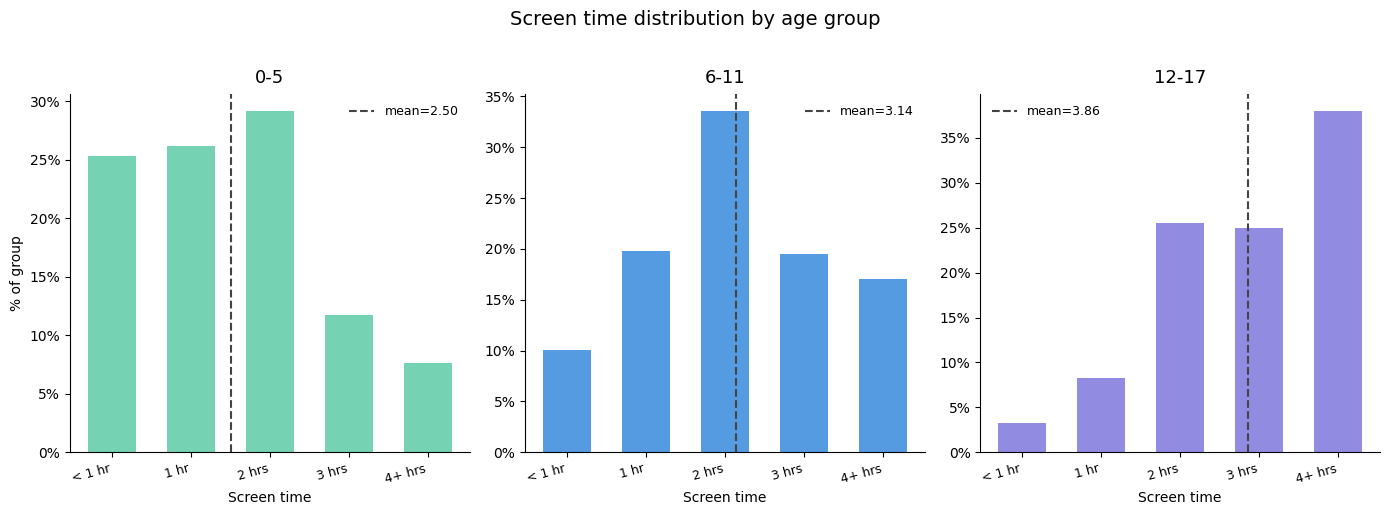

In [88]:
labels = ['< 1 hr', '1 hr', '2 hrs', '3 hrs', '4+ hrs']
groups = ['0-5', '6-11', '12-17']
colors = ['#5DCAA5', '#378ADD', '#7F77DD']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, group, color in zip(axes, groups, colors):
    grp = df[df['AGE_GROUP'] == group]['SCREENTIME'].dropna()
    
    counts = grp.value_counts().sort_index()
    pcts   = counts / counts.sum() * 100
    mean   = grp.mean()

    bars = ax.bar(pcts.index, pcts.values, color=color, alpha=0.85, width=0.6)
    ax.axvline(mean, color='#444', linewidth=1.5, linestyle='--', label=f'mean={mean:.2f}')
    ax.legend(fontsize=9, frameon=False)

    ax.set_title(group, fontsize=13, pad=8)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(labels, fontsize=9, rotation=15, ha='right')
    ax.set_xlabel('Screen time', fontsize=10)
    ax.set_ylabel('% of group' if ax == axes[0] else '', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Screen time distribution by age group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('screentime_by_age.png', dpi=150, bbox_inches='tight')
plt.show()


Correlation matrix for variables

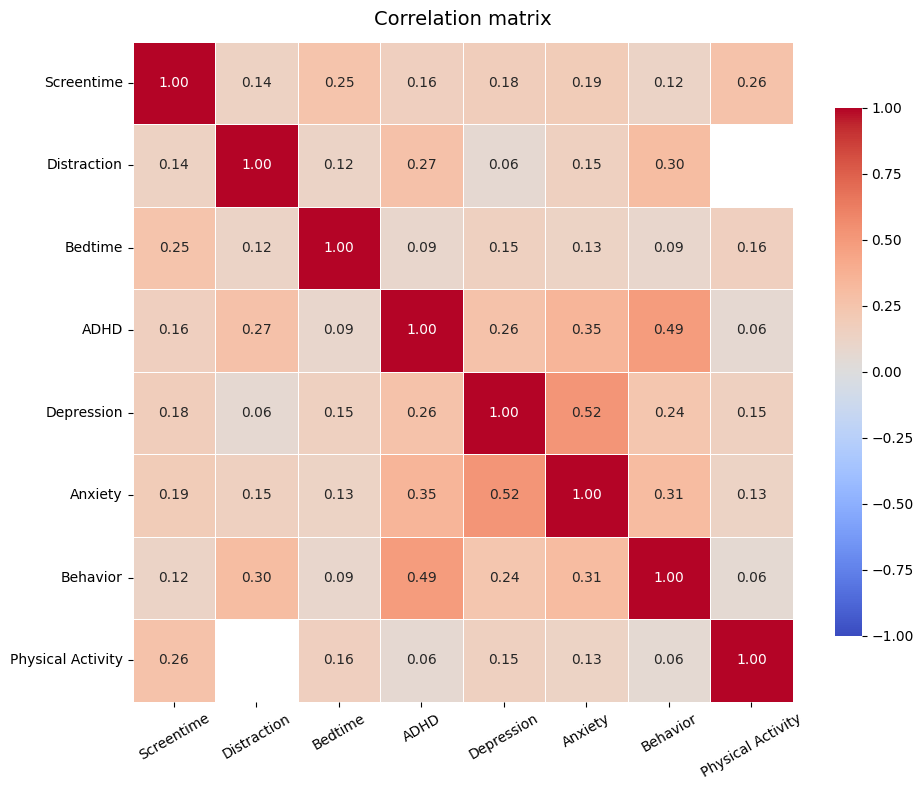

In [89]:
corr_cols = {
    'Screentime':        'SCREENTIME',
    'Distraction':       'DISTRACTED_flipped',
    'Bedtime':           'BEDTIME',
    'ADHD':              'ADHD',
    'Depression':        'DEPRESSION',
    'Anxiety':           'ANXIETY',
    'Behavior':          'BEHAVIOR',
    'Physical Activity': 'PHYSACTIV_flipped',
}

corr_df = df[[col for col in corr_cols.values()]].rename(columns={v: k for k, v in corr_cols.items()})

corr_matrix = corr_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
)

ax.set_title('Correlation matrix', fontsize=14, pad=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Bar charts of screen time by demographics

Side-by-side comparisons across age buckets for all three outcomes

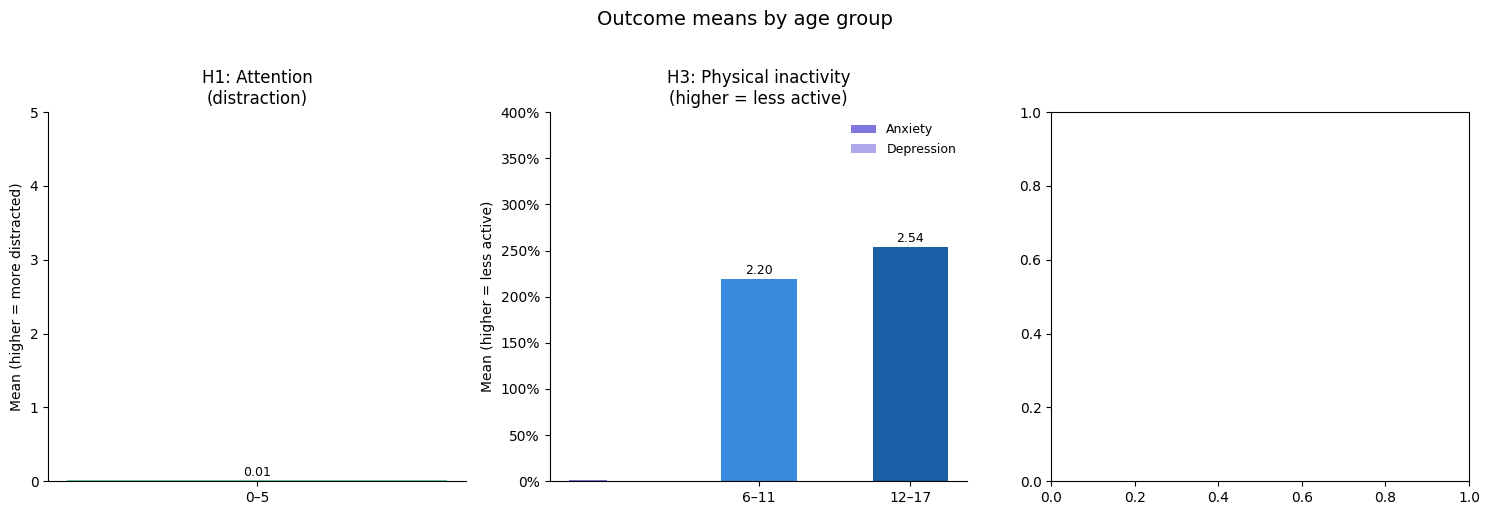

In [ ]:
age_groups = ['0–5', '6–11', '12–17']
x = np.arange(len(age_groups))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# H1: ADHD prevalence across all age groups
ax = axes[0]
adhd_prev = [0.015, 0.131, 0.168]
colors = ['#5DCAA5', '#378ADD', '#7F77DD']
bars = ax.bar(range(3), adhd_prev, color=colors, width=0.5)
ax.set_title('H1: Attention\n(ADHD prevalence)', fontsize=12)
ax.set_xticks(range(3))
ax.set_xticklabels(age_groups)
ax.set_ylabel('Proportion diagnosed')
ax.set_ylim(0, 0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.spines[['top', 'right']].set_visible(False)
for i, val in enumerate(adhd_prev):
    ax.text(i, val + 0.003, f'{val:.1%}', ha='center', fontsize=9)

# H2: Anxiety and depression prevalence
ax = axes[1]
anxiety_prev    = [0.019, 0.122, 0.213]
depression_prev = [0.001, 0.027, 0.126]
ax.bar(x - width/2, anxiety_prev,    width, color='#7F77DD', label='Anxiety')
ax.bar(x + width/2, depression_prev, width, color='#AFA9EC', label='Depression')
ax.set_title('H2: Mental health\n(prevalence)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(age_groups)
ax.set_ylabel('Proportion diagnosed')
ax.set_ylim(0, 0.30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# H3: Physical inactivity (6-11 and 12-17 only)
ax = axes[2]
phys_means = [2.196, 2.539]
phys_colors = ['#378ADD', '#7F77DD']
bars = ax.bar([0, 1], phys_means, color=phys_colors, width=0.5)
ax.set_title('H3: Physical inactivity\n(higher = less active)', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['6–11', '12–17'])
ax.set_ylabel('Mean (1–4 scale)')
ax.set_ylim(0, 4)
ax.spines[['top', 'right']].set_visible(False)
for i, val in enumerate(phys_means):
    ax.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=9)

fig.suptitle('Outcome means by age group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('outcomes_by_age.png', dpi=150, bbox_inches='tight')
plt.show()